# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [8]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [9]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [10]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [12]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [13]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [14]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [15]:
# Diferencias clave entre LabelEncoder y OneHotEncoder
print("Diferencias entre LabelEncoder y OneHotEncoder:\n")
print("1) LabelEncoder asigna un número entero a cada categoría.")
print("   Ejemplo: male=1, female=0")
print("   Riesgo: puede introducir un orden artificial entre categorías.")
print()
print("2) OneHotEncoder (dummies) crea una columna por categoría.")
print("   Ejemplo: embarked_C, embarked_Q, embarked_S")
print("   Ventaja: evita suponer relación de orden entre categorías.")
print()
print("3) LabelEncoder suele usarse en variables objetivo categóricas,")
print("   mientras OneHotEncoder es más adecuado para variables de entrada nominales.")

Diferencias entre LabelEncoder y OneHotEncoder:

1) LabelEncoder asigna un número entero a cada categoría.
   Ejemplo: male=1, female=0
   Riesgo: puede introducir un orden artificial entre categorías.

2) OneHotEncoder (dummies) crea una columna por categoría.
   Ejemplo: embarked_C, embarked_Q, embarked_S
   Ventaja: evita suponer relación de orden entre categorías.

3) LabelEncoder suele usarse en variables objetivo categóricas,
   mientras OneHotEncoder es más adecuado para variables de entrada nominales.


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

Frecuencia original de 'sex':
sex
female    314
male      577
Name: count, dtype: int64

Frecuencia codificada de 'sex_label':
sex_label
0    314
1    577
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

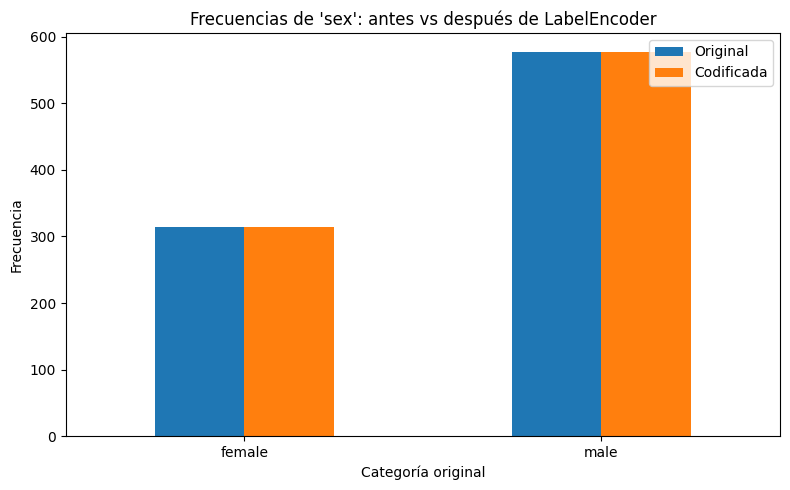

In [16]:
# Frecuencias antes de codificar (sex original)
freq_original = data['sex'].value_counts().sort_index()

# Frecuencias después de codificar con LabelEncoder (sex_label)
freq_codificado = data['sex_label'].value_counts().sort_index()

# Mostrar tablas de frecuencia
print("Frecuencia original de 'sex':")
print(freq_original)
print("\nFrecuencia codificada de 'sex_label':")
print(freq_codificado)

# Gráfica comparativa
tabla_comparacion = pd.DataFrame({
    'sex_original': freq_original.values,
    'sex_label': freq_codificado.values
}, index=freq_original.index)

plt.figure(figsize=(8, 5))
tabla_comparacion.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title("Frecuencias de 'sex': antes vs después de LabelEncoder")
plt.xlabel("Categoría original")
plt.ylabel("Frecuencia")
plt.legend(["Original", "Codificada"], loc='upper right')
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [17]:
# Codificar la columna 'class' usando OneHot (dummies)
class_onehot = pd.get_dummies(data['class'], prefix='class')

data_class_encoded = pd.concat([data, class_onehot], axis=1)

print("Primeras filas con codificación OneHot para 'class':")
display(data_class_encoded[['class', 'class_First', 'class_Second', 'class_Third']].head())

print("\nVentajas de OneHot frente a LabelEncoder para 'class':")
print("- No impone una relación ordinal artificial entre categorías.")
print("- Cada clase se representa de forma independiente (más interpretable).")
print("- Suele mejorar el rendimiento en modelos lineales y basados en distancia.")

Primeras filas con codificación OneHot para 'class':


,class,class_First,class_Second,class_Third
0,Third,False,False,True
1,First,True,False,False
2,Third,False,False,True
3,First,True,False,False
4,Third,False,False,True



Ventajas de OneHot frente a LabelEncoder para 'class':
- No impone una relación ordinal artificial entre categorías.
- Cada clase se representa de forma independiente (más interpretable).
- Suele mejorar el rendimiento en modelos lineales y basados en distancia.


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [18]:
# Recomendación de codificación para ML
print("Para variables categóricas nominales (sin orden), elegiría OneHotEncoder.")
print("Ejemplos: sex, embarked, class como etiquetas nominales.")
print()
print("Usaría LabelEncoder solo cuando:")
print("- La variable es el objetivo (y) categórico, o")
print("- Existe un orden real entre categorías (ordinal) y se respeta ese orden.")
print()
print("En este dataset, para la mayoría de variables categóricas de entrada,")
print("OneHotEncoder es la opción más segura para evitar sesgos por orden artificial.")

Para variables categóricas nominales (sin orden), elegiría OneHotEncoder.
Ejemplos: sex, embarked, class como etiquetas nominales.

Usaría LabelEncoder solo cuando:
- La variable es el objetivo (y) categórico, o
- Existe un orden real entre categorías (ordinal) y se respeta ese orden.

En este dataset, para la mayoría de variables categóricas de entrada,
OneHotEncoder es la opción más segura para evitar sesgos por orden artificial.
